# NB16 --- Difficulte F : plus de structure qu'aux niveaux B-E ? (RQ2)
### NB16 --- Difficulty F: More Structure Than Levels B-E? (RQ2)

**Contexte.** NB11 (12 problemes, B-E) concluait a un signal reel mais modeste, sans
tendance liee a la difficulte. Aucun probleme F n'etait dans ce corpus. Question :
est-ce que F --- le niveau le plus dur, population de solveurs probablement plus
homogene --- montre une separation plus nette, ou le meme plafond ?

**Corpus.** 3 problemes F choisis pour leur equilibre reel entre verdicts (verifie
avant de lancer, pas par volume total seul) : p02698 (le plus equilibre des 4
verdicts), p02599 (TLE tres riche), p02788 (bon volume global). n=100/verdict.
4 methodes : TF-IDF, CodeBERT, GraphCodeBERT (naif), GraphCodeBERT-ast (vrai DFG).

**Note sur les noms de fichiers.** tfidf/codebert/graphcodebert portent un suffixe
`_cls` qui ne veut rien dire pour eux (bug de tag corrige dans embedding.py, mais les
fichiers deja generes gardent ce nom -- pas relance pour un probleme cosmetique).

---

**Context.** NB11 (12 problems, B-E) found a real but modest signal, no
difficulty-related trend. No F-difficulty problem was in that corpus. Question: does
F --- the hardest level, likely a more homogeneous solver population --- show a
cleaner separation, or the same ceiling?

**Corpus.** 3 F-difficulty problems chosen for genuine balance across verdicts
(checked before running, not just total volume): p02698 (most balanced across all 4
verdicts), p02599 (TLE-rich), p02788 (good overall volume). n=100/verdict. 4 methods:
TF-IDF, CodeBERT, GraphCodeBERT (naive), GraphCodeBERT-ast (real DFG).

**Note on filenames.** tfidf/codebert/graphcodebert carry a meaningless `_cls` suffix
(a tagging bug, fixed in embedding.py, but the already-generated files keep this name
-- not worth rerunning just for a cosmetic issue).

In [1]:
import sys
import numpy as np
import polars as pl
import matplotlib.pyplot as plt
from pathlib import Path

_cwd = Path.cwd()
PROJECT_ROOT = _cwd if (_cwd / "src").exists() else _cwd.parent
sys.path.insert(0, str(PROJECT_ROOT / "src"))

EMBEDDINGS_DIR = PROJECT_ROOT / "data" / "processed" / "embeddings"
print(f"EMBEDDINGS_DIR: {EMBEDDINGS_DIR}  (exists={EMBEDDINGS_DIR.exists()})")

STATUS_COLORS = {'AC': '#2ecc71', 'WA': '#e74c3c', 'TLE': '#e67e22', 'CE': '#9b59b6', 'RE': '#3498db'}
GROUP_COLORS = {'G1': '#c0392b', 'G2': '#e67e22', 'G3': '#f1c40f', 'G4': '#2ecc71', 'G5': '#3498db', 'G6': '#9b59b6'}
STATUSES_ORDER = ['AC', 'WA', 'TLE', 'CE', 'RE']
GROUPS_ORDER   = ['G1', 'G2', 'G3', 'G4', 'G5', 'G6']
TARGET_LABELS  = ['status_code', 'proficiency_group']
LABEL_NAMES    = {'status_code': 'verdict', 'proficiency_group': 'groupe'}
label_style    = {'status_code': (STATUS_COLORS, STATUSES_ORDER), 'proficiency_group': (GROUP_COLORS, GROUPS_ORDER)}

EMBEDDINGS_DIR: /Users/raphael/OJS-submission-analytics/data/processed/embeddings  (exists=True)


## S0 --- Generation du corpus
### S0 --- Corpus Generation

```bash
python src/embedding.py tfidf cpu Python "p02698,p02599,p02788" 100
python src/embedding.py codebert mps Python "p02698,p02599,p02788" 100
python src/embedding.py graphcodebert mps Python "p02698,p02599,p02788" 100
python src/embedding.py graphcodebert_ast mps Python "p02698,p02599,p02788" 100
```

In [2]:
METHODS = {
    "tfidf":            "tfidf_python_multi3_n100_cls",
    "codebert":         "codebert_python_multi3_n100_cls",
    "graphcodebert":    "graphcodebert_python_multi3_n100_cls",
    "graphcodebert_ast":"graphcodebert_ast_python_multi3_n100",
}

embeddings, df_meta = {}, {}
for name, tag in METHODS.items():
    emb_path, meta_path = EMBEDDINGS_DIR / f"embeddings_{tag}.npy", EMBEDDINGS_DIR / f"metadata_{tag}.csv"
    if not emb_path.exists():
        print(f"[MANQUANT] {name} ({tag})")
        continue
    embeddings[name] = np.load(emb_path)
    df_meta[name] = pl.read_csv(meta_path)
    m = df_meta[name]
    print(f"{name:18s} : {embeddings[name].shape}  |  {m.height:,} soumissions  |  {m['problem_id'].n_unique()} problemes")

methods_present = list(embeddings.keys())
pid_list = sorted(df_meta[methods_present[0]]["problem_id"].unique().to_list())
print(f"\nMethodes: {methods_present}\nProblemes: {pid_list}")

tfidf              : (1200, 10000)  |  1,200 soumissions  |  3 problemes
codebert           : (1200, 768)  |  1,200 soumissions  |  3 problemes
graphcodebert      : (1200, 768)  |  1,200 soumissions  |  3 problemes
graphcodebert_ast  : (1200, 768)  |  1,200 soumissions  |  3 problemes

Methodes: ['tfidf', 'codebert', 'graphcodebert', 'graphcodebert_ast']
Problemes: ['p02599', 'p02698', 'p02788']


## S1 --- Criblage quantitatif : lift k-NN par probleme
### S1 --- Quantitative Screening: k-NN Lift per Problem

Meme protocole que NB11 S2 / NB12 / NB13 : par probleme, k=10 voisins cosinus,
coherence de voisinage comparee a la baseline Sigma-p-carre.

In [3]:
from sklearn.neighbors import NearestNeighbors

K = 10
s1_rows = []
for name in methods_present:
    emb, meta = embeddings[name], df_meta[name]
    for pid in pid_list:
        idx = np.where((meta["problem_id"] == pid).to_numpy())[0]
        sub_emb = emb[idx]
        for label in TARGET_LABELS:
            labels_arr = meta[label].to_numpy()[idx]
            classes, counts = np.unique(labels_arr, return_counts=True)
            if len(classes) < 2 or len(labels_arr) < K + 1:
                continue
            baseline = float(np.sum((counts / counts.sum()) ** 2))
            nbrs = NearestNeighbors(n_neighbors=K + 1, metric="cosine", algorithm="brute").fit(sub_emb)
            _, nn_idx = nbrs.kneighbors(sub_emb)
            matches, total = 0, 0
            for i in range(len(labels_arr)):
                neigh = nn_idx[i, 1:]
                matches += int(np.sum(labels_arr[neigh] == labels_arr[i]))
                total += len(neigh)
            cons = matches / total
            s1_rows.append({
                "method": name, "problem_id": pid, "label": LABEL_NAMES[label],
                "n": len(labels_arr), "baseline": round(baseline, 3),
                "consistency": round(cons, 3), "lift": round(cons / baseline, 3) if baseline > 0 else float("nan"),
            })

df_s1 = pl.DataFrame(s1_rows)
piv = df_s1.pivot(on="method", index=["problem_id", "label"], values="lift").sort(["label", "problem_id"])
print(f"Moyenne du lift, par methode :")
print(df_s1.group_by("method").agg(pl.col("lift").mean().round(3).alias("lift_moyen")).sort("lift_moyen", descending=True))
piv

Moyenne du lift, par methode :
shape: (4, 2)
┌───────────────────┬────────────┐
│ method            ┆ lift_moyen │
│ ---               ┆ ---        │
│ str               ┆ f64        │
╞═══════════════════╪════════════╡
│ graphcodebert_ast ┆ 1.21       │
│ graphcodebert     ┆ 1.202      │
│ tfidf             ┆ 1.185      │
│ codebert          ┆ 1.165      │
└───────────────────┴────────────┘


problem_id,label,tfidf,codebert,graphcodebert,graphcodebert_ast
str,str,f64,f64,f64,f64
"""p02599""","""groupe""",1.154,1.176,1.194,1.192
"""p02698""","""groupe""",1.014,1.013,1.014,1.015
"""p02788""","""groupe""",1.061,1.041,1.039,1.08
"""p02599""","""verdict""",1.42,1.395,1.466,1.465
"""p02698""","""verdict""",1.259,1.213,1.32,1.37
"""p02788""","""verdict""",1.2,1.154,1.181,1.138


## S2 --- t-SNE, galerie complete (3 problemes x 4 methodes x 2 etiquettes)
### S2 --- t-SNE, Full Gallery (3 Problems x 4 Methods x 2 Labels)

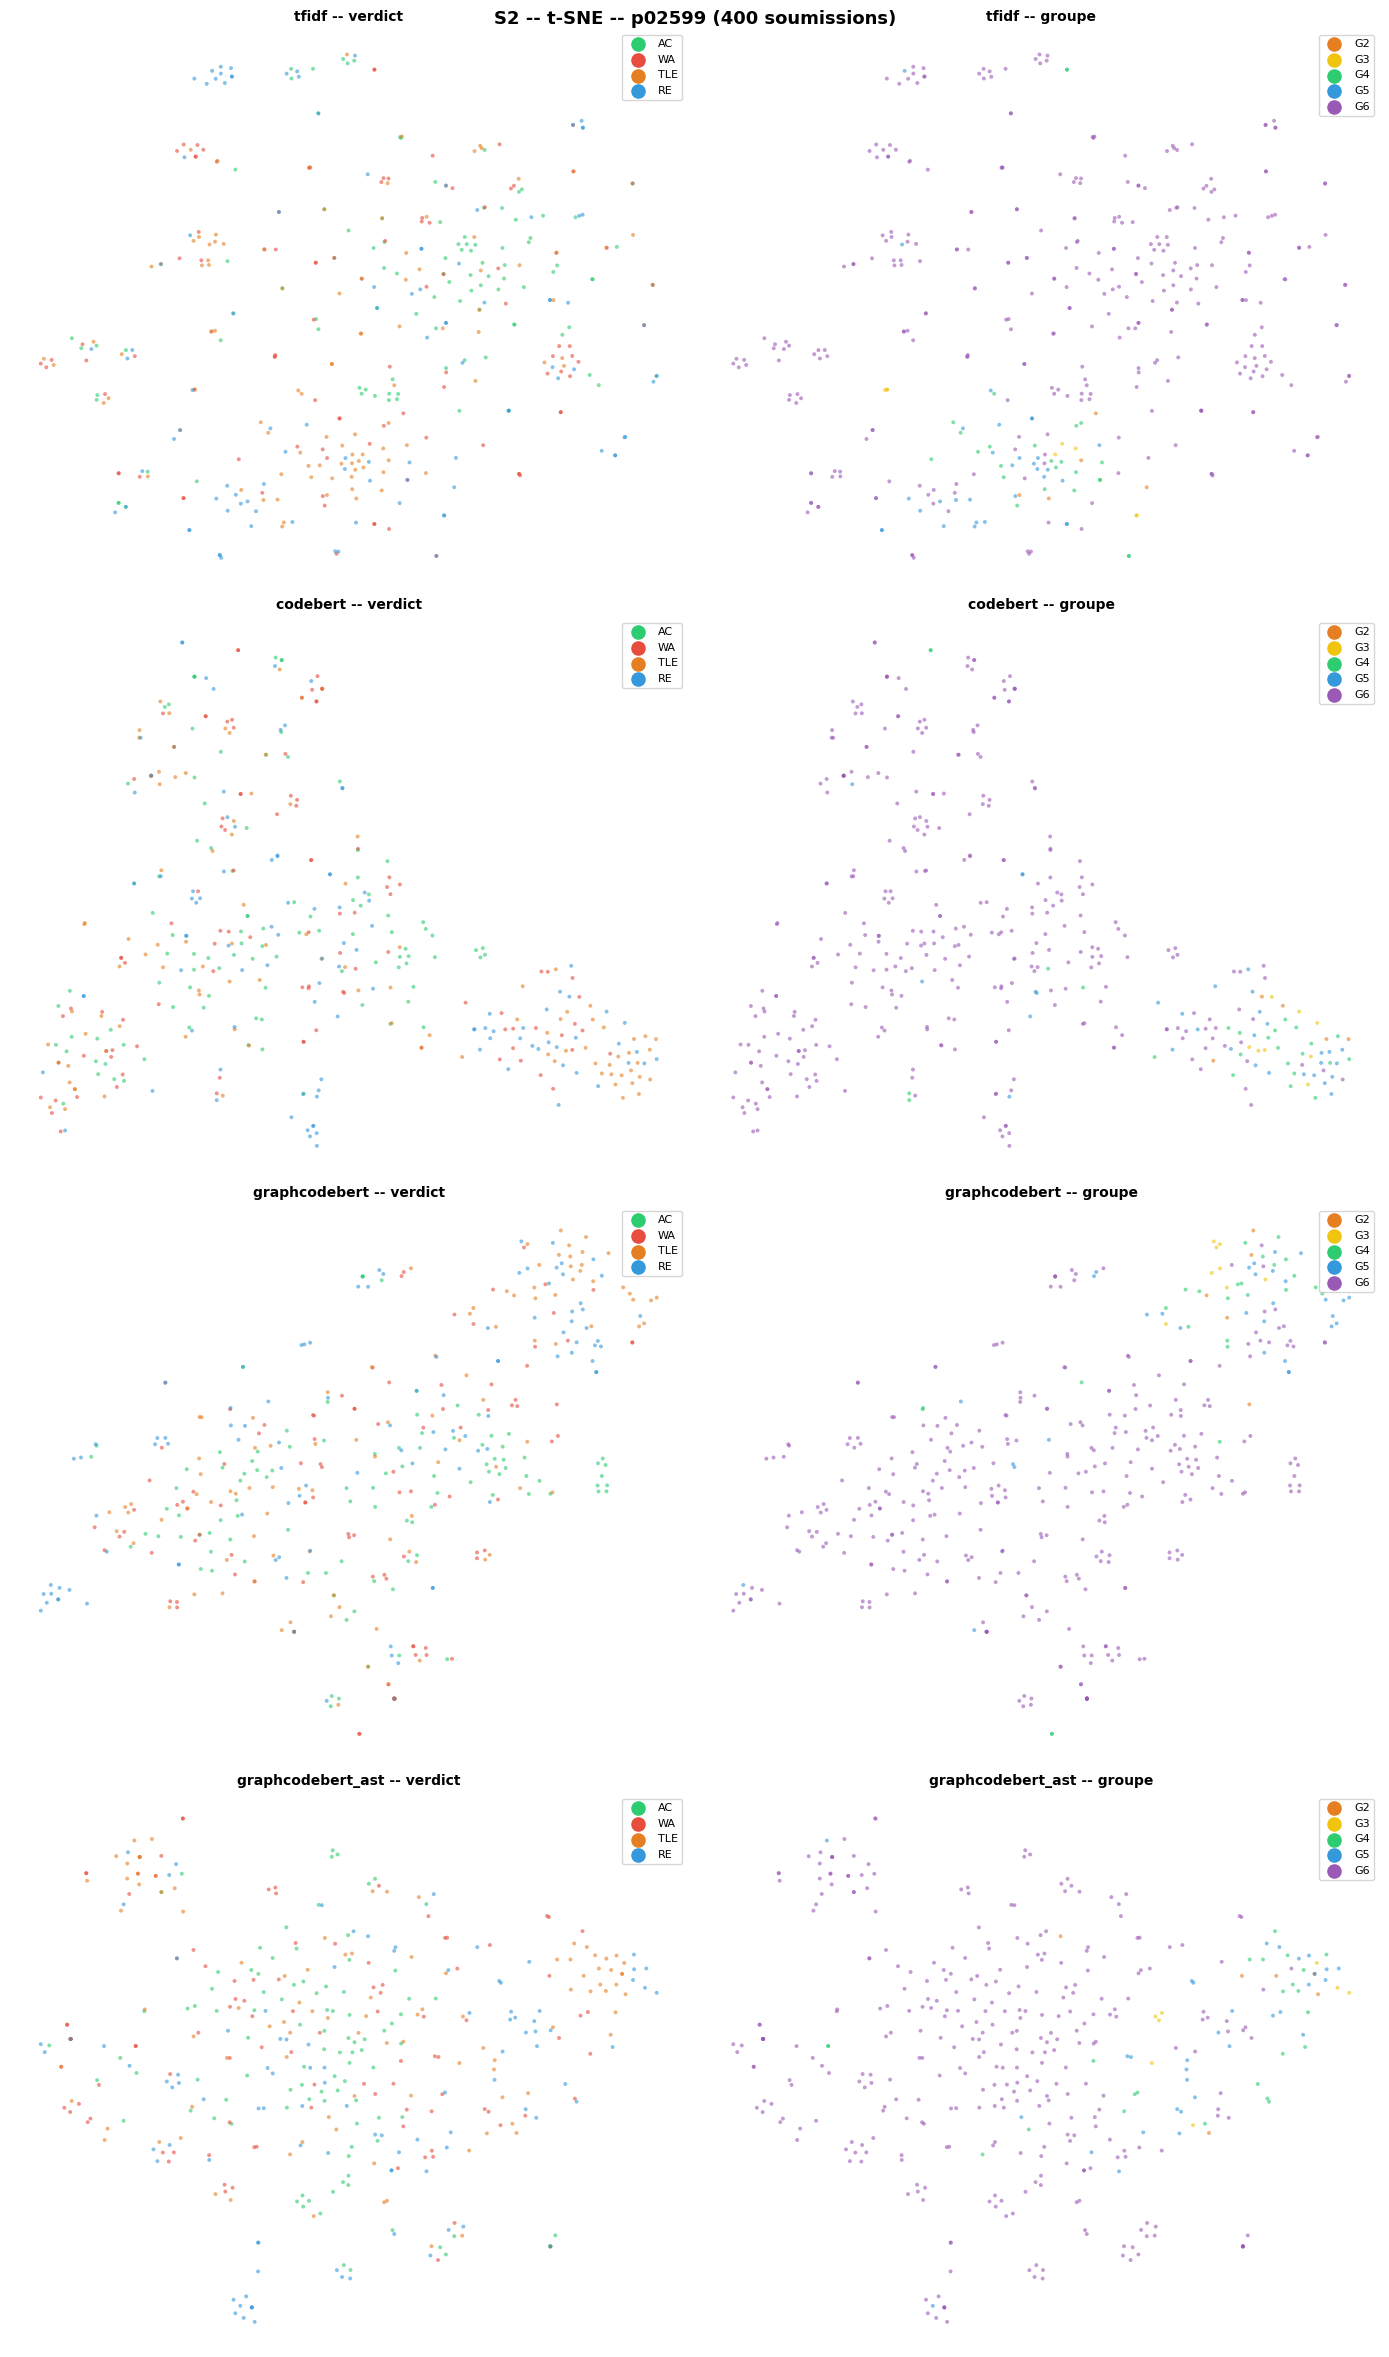

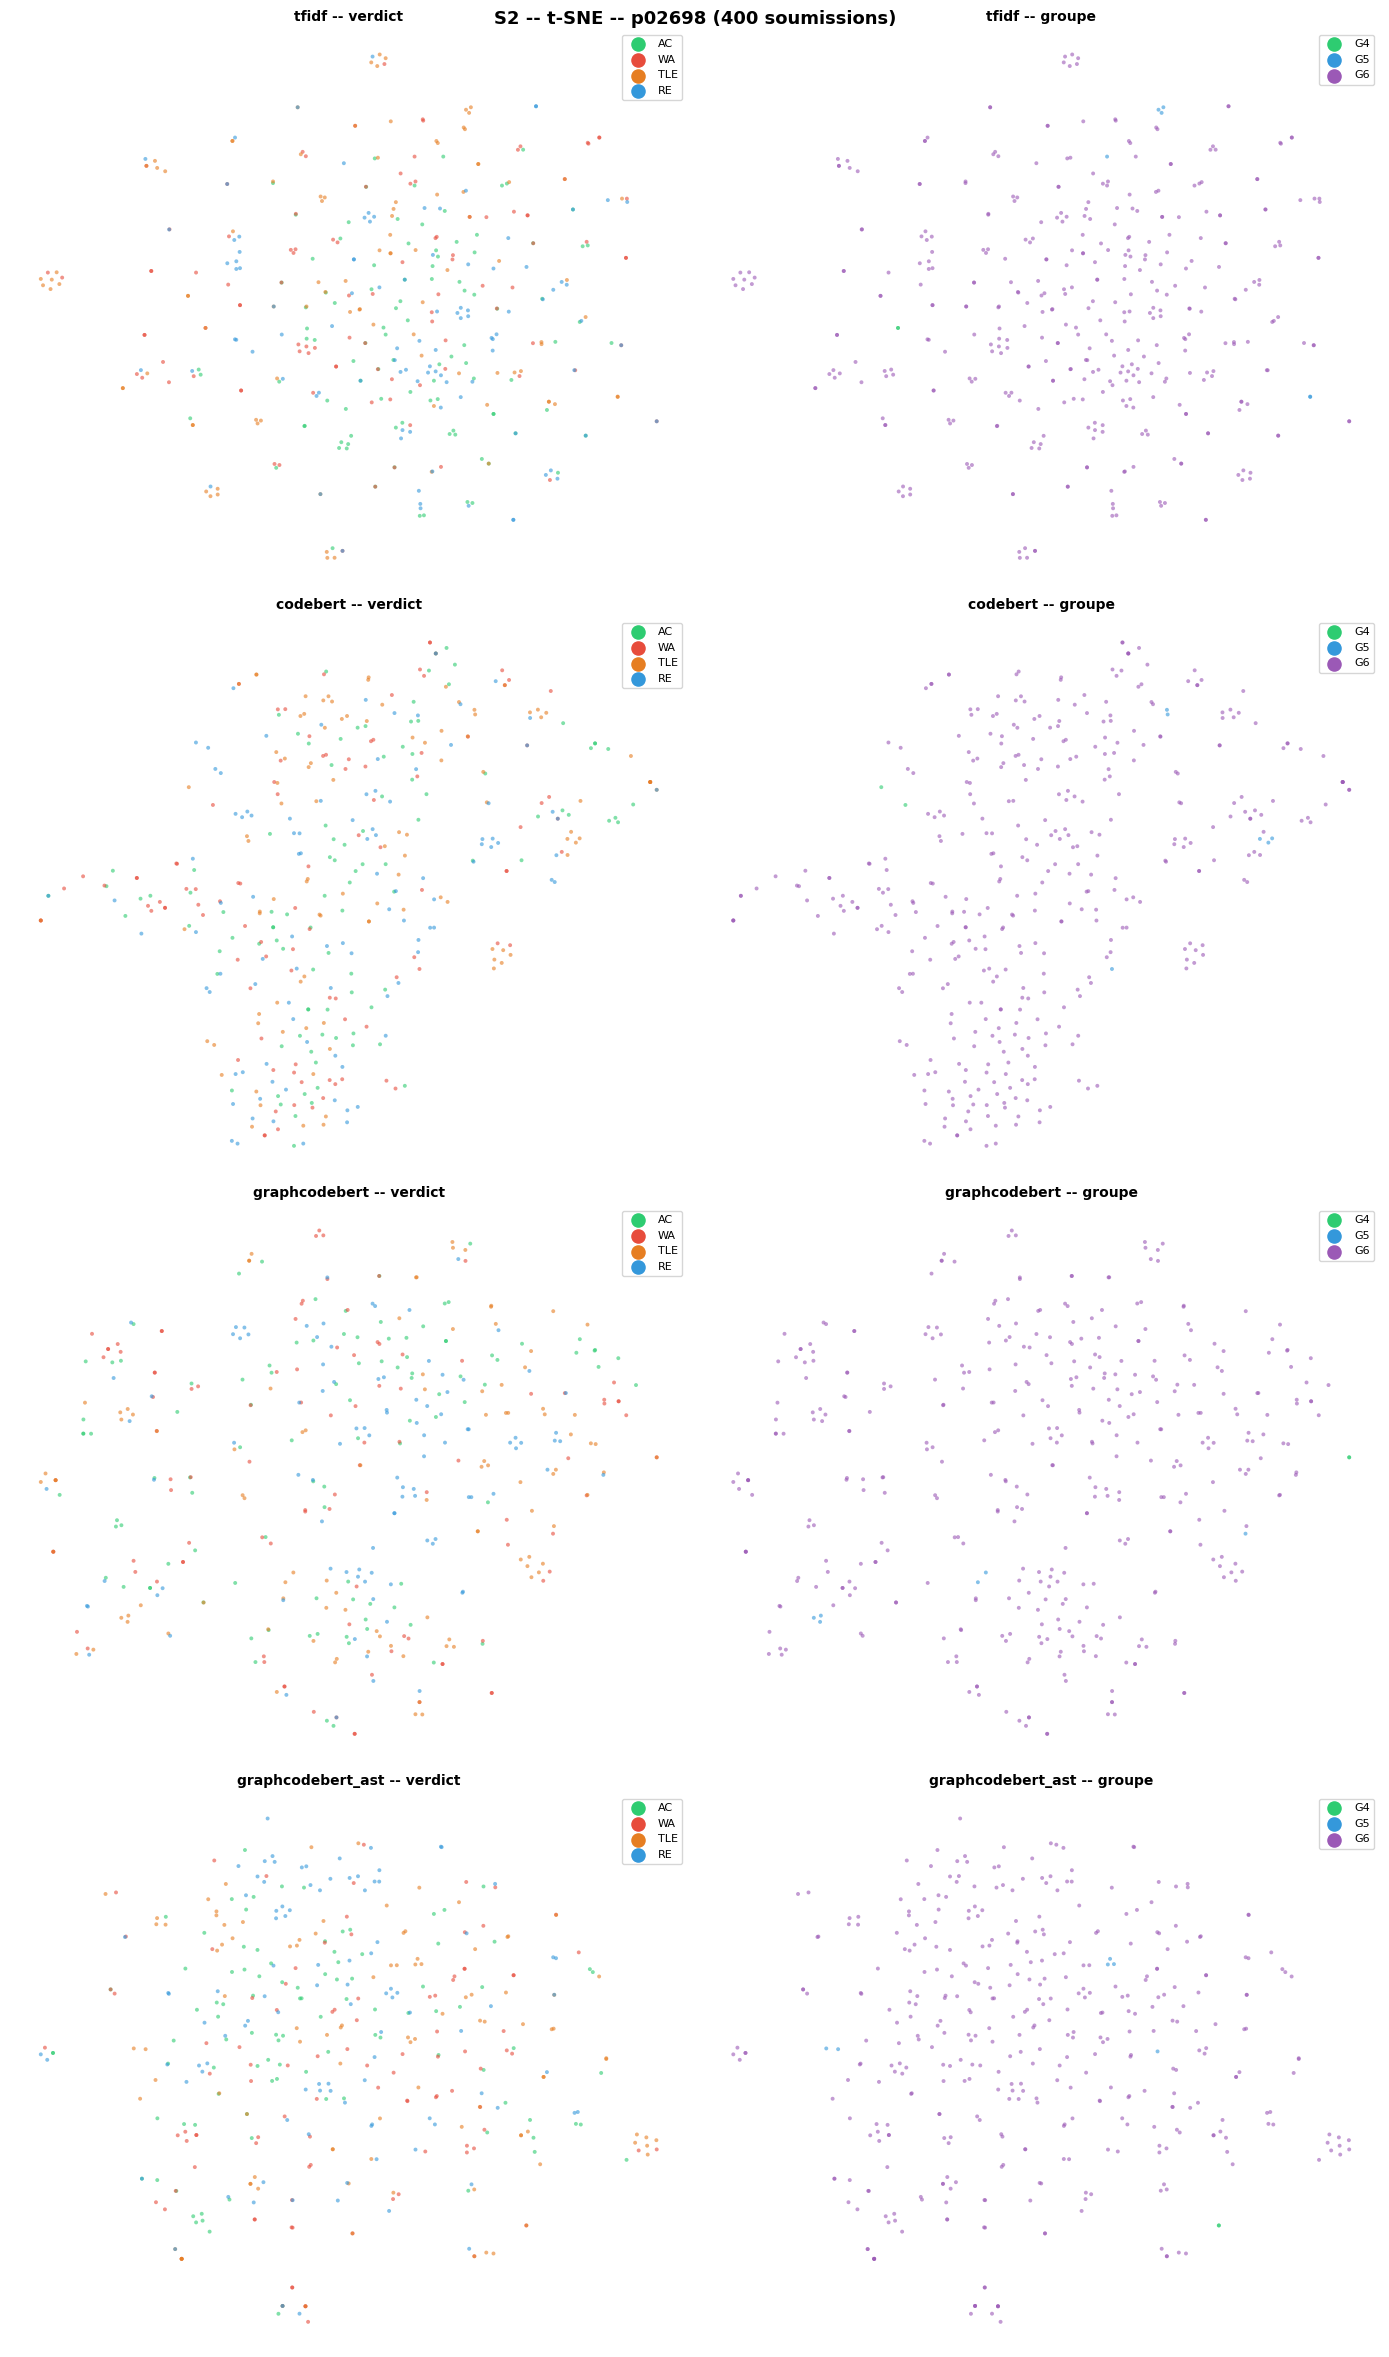

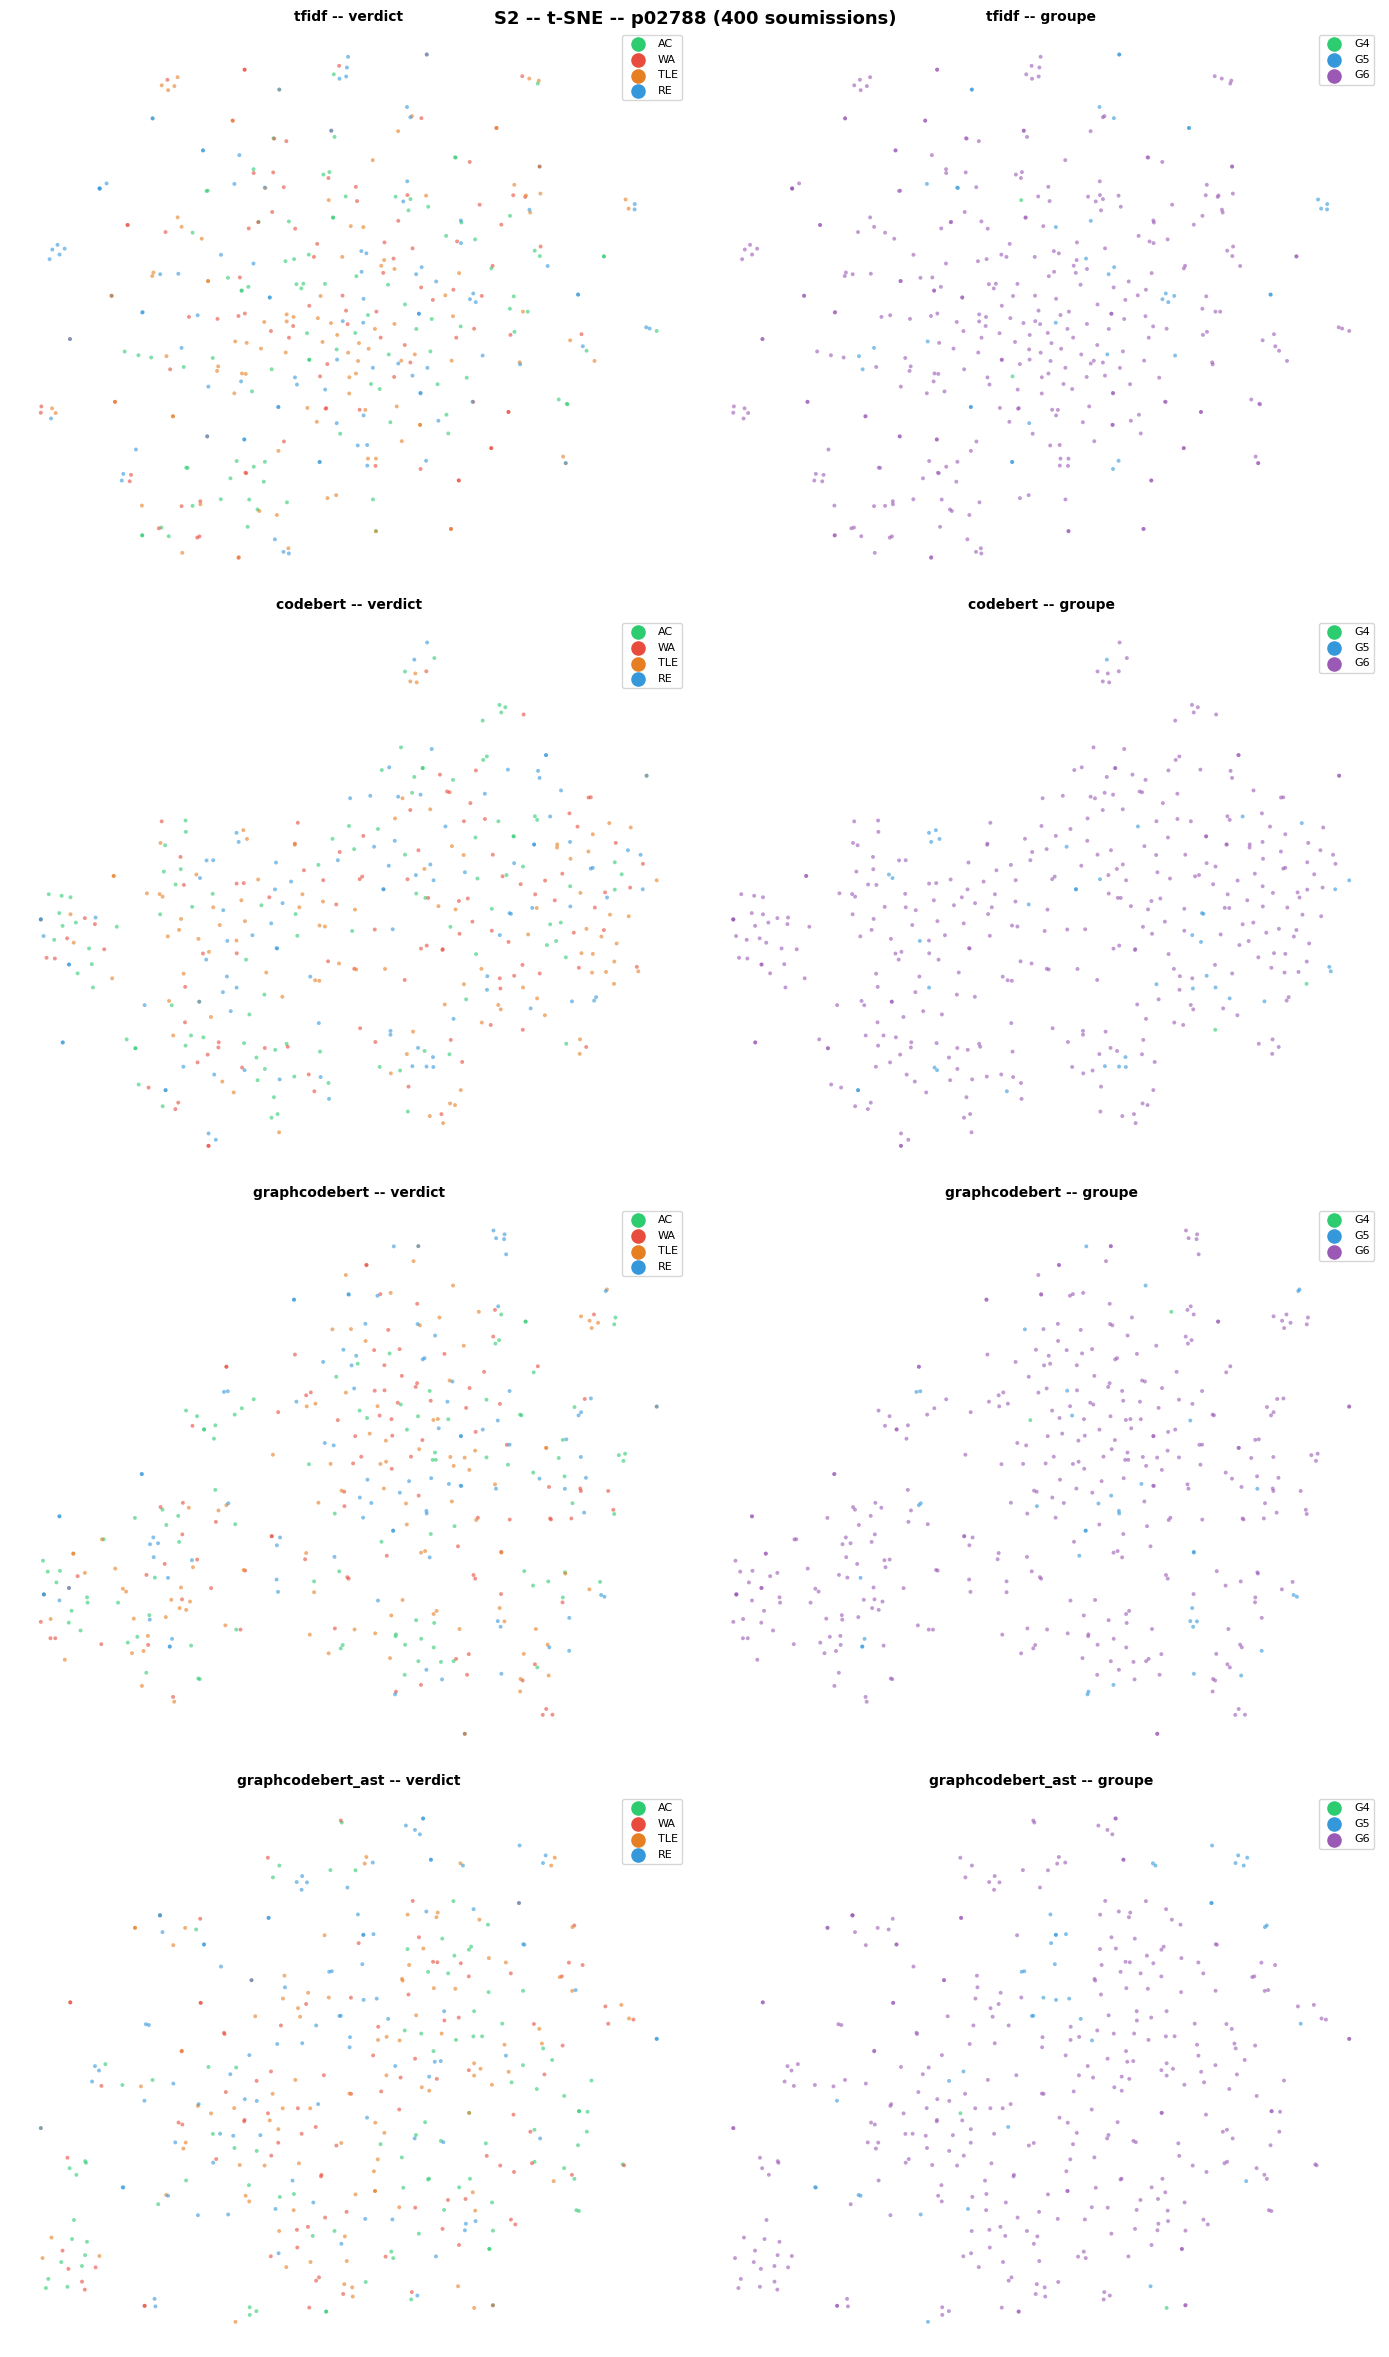

In [4]:
from sklearn.manifold import TSNE

for pid in pid_list:
    fig, axes = plt.subplots(len(methods_present), len(TARGET_LABELS),
                             figsize=(7 * len(TARGET_LABELS), 6 * len(methods_present)))
    axes = np.atleast_2d(axes)
    if axes.shape != (len(methods_present), len(TARGET_LABELS)):
        axes = axes.reshape(len(methods_present), len(TARGET_LABELS))

    n_this = 0
    for row_i, name in enumerate(methods_present):
        meta = df_meta[name]
        idx = np.where((meta["problem_id"] == pid).to_numpy())[0]
        n_this = len(idx)
        sub_emb, sub_meta = embeddings[name][idx], meta[idx]

        tsne = TSNE(n_components=2, random_state=42, metric="cosine", init="pca",
                    perplexity=min(30, n_this - 1))
        proj = tsne.fit_transform(sub_emb)

        for col_i, label in enumerate(TARGET_LABELS):
            ax = axes[row_i, col_i]
            colors_map, order = label_style[label]
            vals = sub_meta[label].to_list()
            ax.scatter(proj[:, 0], proj[:, 1], c=[colors_map.get(v, "#aaaaaa") for v in vals],
                      s=8, alpha=0.6, linewidths=0)
            for v in order:
                if v in vals:
                    ax.scatter([], [], c=colors_map[v], s=35, label=v)
            ax.legend(fontsize=8, markerscale=1.6, framealpha=0.8)
            ax.set_title(f"{name} -- {LABEL_NAMES[label]}", fontsize=10, fontweight="bold")
            ax.axis("off")

    plt.suptitle(f"S2 -- t-SNE -- {pid} ({n_this} soumissions)", fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.show()

## S3 --- Sonde supervisee
### S3 --- Supervised Probe

Meme protocole que NB13 S8 : regression logistique + StandardScaler, 5-fold
stratifie, par probleme, comparee a la baseline classe majoritaire.

In [5]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.dummy import DummyClassifier

s3_rows = []
for name in methods_present:
    emb, meta = embeddings[name], df_meta[name]
    for pid in pid_list:
        idx = np.where((meta["problem_id"] == pid).to_numpy())[0]
        if len(idx) < 50:
            continue
        sub_emb = emb[idx]
        y = meta["status_code"].to_numpy()[idx]
        classes, counts = np.unique(y, return_counts=True)
        if len(classes) < 2 or counts.min() < 5:
            continue
        n_splits = min(5, counts.min())
        skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
        clf = make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000))
        probe_acc = cross_val_score(clf, sub_emb, y, cv=skf, scoring="accuracy").mean()
        dummy_acc = cross_val_score(DummyClassifier(strategy="most_frequent"), sub_emb, y, cv=skf, scoring="accuracy").mean()
        s3_rows.append({"method": name, "problem_id": pid, "n": len(idx),
                        "probe_acc": round(probe_acc, 4), "dummy_acc": round(dummy_acc, 4),
                        "lift": round(probe_acc - dummy_acc, 4)})

df_s3 = pl.DataFrame(s3_rows)
print(df_s3.group_by("method").agg([
    pl.col("probe_acc").mean().round(3).alias("probe_acc_moyen"),
    pl.col("dummy_acc").mean().round(3).alias("dummy_acc_moyen"),
]).sort("probe_acc_moyen", descending=True))
df_s3.sort(["method", "problem_id"])

shape: (4, 3)
┌───────────────────┬─────────────────┬─────────────────┐
│ method            ┆ probe_acc_moyen ┆ dummy_acc_moyen │
│ ---               ┆ ---             ┆ ---             │
│ str               ┆ f64             ┆ f64             │
╞═══════════════════╪═════════════════╪═════════════════╡
│ tfidf             ┆ 0.477           ┆ 0.25            │
│ codebert          ┆ 0.472           ┆ 0.25            │
│ graphcodebert     ┆ 0.468           ┆ 0.25            │
│ graphcodebert_ast ┆ 0.462           ┆ 0.25            │
└───────────────────┴─────────────────┴─────────────────┘


method,problem_id,n,probe_acc,dummy_acc,lift
str,str,i64,f64,f64,f64
"""codebert""","""p02599""",400,0.4625,0.25,0.2125
"""codebert""","""p02698""",400,0.495,0.25,0.245
"""codebert""","""p02788""",400,0.46,0.25,0.21
"""graphcodebert""","""p02599""",400,0.4825,0.25,0.2325
"""graphcodebert""","""p02698""",400,0.485,0.25,0.235
…,…,…,…,…,…
"""graphcodebert_ast""","""p02698""",400,0.5225,0.25,0.2725
"""graphcodebert_ast""","""p02788""",400,0.4075,0.25,0.1575
"""tfidf""","""p02599""",400,0.4575,0.25,0.2075


## S4 --- Synthese
### S4 --- Synthesis

**1. Le lift k-NN est comparable entre les 4 methodes, et modeste.**
graphcodebert_ast 1,21 / graphcodebert 1,202 / tfidf 1,185 / codebert 1,165
--- toutes dans un mouchoir de poche, aucune methode qui se detache
nettement.

**2. La sonde confirme : F fait moins bien que B-E, pas mieux.** tfidf
47,7 % / codebert 47,2 % / graphcodebert 46,8 % / graphcodebert_ast 46,2 %
(baseline 25 %). A comparer aux ~55 % de moyenne de graphcodebert_ast sur
B-E (jusqu'a 65 % sur B et C individuellement) --- F est clairement en
dessous, pas au-dessus.

**3. L'avantage de graphcodebert_ast s'inverse --- le resultat le plus
marquant.** Sur B-E, graphcodebert_ast etait systematiquement la meilleure
methode. Sur F, il devient le pire des 4 (46,2 %, dernier). Le mecanisme de
graphe qui aide sur les problemes plus simples n'aide plus sur les plus
durs --- et nuit meme legerement.

**4. Hypothese de depart rejetee.** Le notebook posait la question : les
problemes durs (solveurs plus homogenes) montrent-ils un signal plus net ?
Non, l'inverse. Coherent avec la tendance deja observee sur B-E seul (B/C
~65 % -> D ~50 % -> E ~46,5 %) : la difficulte est negativement correlee a
la predictibilite du verdict, et F prolonge cette tendance plutot que de la
casser.

**5. Limite a noter.** Corpus a n=100/verdict (400/probleme), plus petit
que le corpus B-E (jusqu'a ~2000/probleme) --- un plus grand echantillon
pourrait affiner les chiffres, mais l'ecart avec B-E est trop large et trop
coherent avec la tendance deja etablie pour qu'un run plus gros change la
conclusion qualitative.

---

**1. k-NN lift is comparable across the 4 methods, and modest.**
graphcodebert_ast 1.21 / graphcodebert 1.202 / tfidf 1.185 / codebert 1.165
--- all within a narrow band, no method clearly ahead.

**2. The probe confirms: F does worse than B-E, not better.** tfidf 47.7% /
codebert 47.2% / graphcodebert 46.8% / graphcodebert_ast 46.2% (baseline
25%). Compare to graphcodebert_ast's ~55% average on B-E (up to 65% on B
and C individually) --- F is clearly below, not above.

**3. GraphCodeBERT-ast's advantage inverts --- the most notable result.**
On B-E, graphcodebert_ast was consistently the best method. On F, it
becomes the worst of the 4 (46.2%, last). The graph mechanism that helps on
easier problems no longer helps on the hardest ones --- and even hurts
slightly.

**4. Starting hypothesis rejected.** The notebook asked: do harder problems
(a more homogeneous solver population) show a cleaner signal? No, the
opposite. Consistent with the trend already seen within B-E alone (B/C
~65% -> D ~50% -> E ~46.5%): difficulty is negatively correlated with
verdict predictability, and F extends this trend rather than breaking it.

**5. A limit worth noting.** Corpus at n=100/verdict (400/problem), smaller
than the B-E corpus (up to ~2000/problem) --- a larger sample could refine
the numbers, but the gap with B-E is too wide and too consistent with the
already-established trend for a bigger run to change the qualitative
conclusion.